In [1]:
import cooler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

In [2]:
# Load cooler file
clr = cooler.Cooler("/project/fudenber_735/GEO/Hsieh2019/4DN/mESC_mm10_4DNFILZ1CPT8.mapq_30.8192.cool")

# Load stripes from bedpe
bedpe_path = "/scratch1/smaruj/stripepy_stripes/Hsieh2019_stripes.8192_detailed.bedpe"
stripes_df = pd.read_csv(bedpe_path, sep='\t')

In [3]:
stripes_df

,chrom1,start1,end1,chrom2,start2,end2,top_persistence,inner_mean,inner_std,outer_lsum,...,outer_rsize,min,q1,q2,q3,max,outer_lmean,outer_rmean,outer_mean,rel_change
0,chr1,3080192,4325376,chr1,3047424,3096576,0.062849,0.124596,0.079398,58.012646,...,459,0.0,0.094508,0.119256,0.154136,0.629521,0.126389,0.140078,0.133233,6.483162
1,chr1,3121152,4136960,chr1,3096576,3153920,0.123977,0.115349,0.091992,50.606641,...,375,0.0,0.059628,0.094508,0.167397,0.675172,0.134951,0.153452,0.144201,20.008292
2,chr1,3178496,4341760,chr1,3162112,3194880,0.055595,0.145149,0.084073,26.281759,...,429,0.0,0.094508,0.138452,0.178884,0.668216,0.061263,0.159464,0.110363,31.519521
3,chr1,3211264,4349952,chr1,3194880,3244032,0.079448,0.142320,0.087891,59.076068,...,420,0.0,0.094508,0.138452,0.178884,0.701985,0.140657,0.128250,0.134454,5.850220
4,chr1,3244032,3694592,chr1,3244032,3260416,0.136932,0.209936,0.095683,27.095119,...,168,0.0,0.167397,0.198080,0.234348,0.701985,0.161280,0.163516,0.162398,29.272392
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32970,chrY,4243456,4259840,chrY,3825664,4243456,0.081486,0.047195,0.088092,5.620360,...,156,0.0,0.000000,0.000000,0.063178,0.552054,0.036028,0.049593,0.042810,10.241290
32971,chrY,4276224,4358144,chrY,4259840,4308992,0.335457,0.145241,0.147313,4.530331,...,33,0.0,0.063178,0.100135,0.177363,0.578382,0.137283,0.103087,0.120185,20.848509
32972,chrY,4259840,4317184,chrY,3997696,4284416,0.405319,0.057953,0.103534,5.214158,...,108,0.0,0.000000,0.000000,0.063178,0.578382,0.048279,0.053830,0.051055,13.511454
32973,chrY,4317184,4349952,chrY,4268032,4333568,0.041835,0.156892,0.135823,4.484383,...,27,0.0,0.063178,0.126356,0.189534,0.520182,0.166088,0.106269,0.136178,15.210400


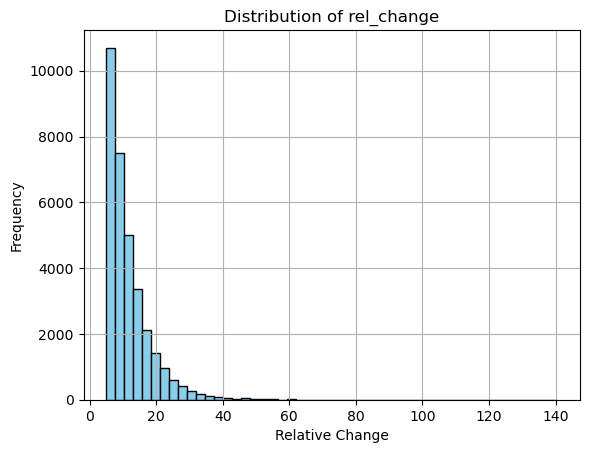

In [4]:
import matplotlib.pyplot as plt

plt.hist(stripes_df['rel_change'], bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Relative Change')
plt.ylabel('Frequency')
plt.title('Distribution of rel_change')
plt.grid(True)
plt.show()

In [6]:
from tqdm import tqdm

In [7]:
def annotate_missing_fraction_bbox(
    df,
    cool_path,
    res,
    halfwin=5,
    use_pixels=False,
    balance=True,
    show_progress=True
):
    """
    For every (intra-chromosomal) stripe defined by
    (chrom1,start1,end1, chrom2,start2,end2),
    compute the fraction of missing data inside the rectangle defined by:
      [bin(start1)..bin(end1)] x [bin(start2)..bin(end2)]
    expanded by ±halfwin bins on all four sides.

    Missingness:
      - use_pixels=False: based on bins.weight being NaN (fast proxy).
      - use_pixels=True : based on NaN pixels in the (balanced) matrix slice (slower, exact).
    """
    c = cooler.Cooler(cool_path)

    chrom_extents = {chrom: c.extent(chrom) for chrom in c.chromnames}
    if not use_pixels:
        bins = c.bins()[:]
        bad_bins = bins["weight"].isna() if "weight" in bins.columns else pd.Series(False, index=bins.index)

    def pos2bin_start(chrom, pos):
        """0-based bin index for 'start' coordinate."""
        start, _ = chrom_extents[chrom]
        return start + (pos // res)

    def pos2bin_end(chrom, pos):
        """Inclusive bin index for 'end' coordinate (subtract 1 to be in the bin)."""
        start, _ = chrom_extents[chrom]
        return start + ((pos - 1) // res)

    it = df.itertuples(index=False)
    if show_progress:
        it = tqdm(it, total=len(df), desc="Annotating missing fractions (bbox)")

    fracs = []
    for row in it:
        if row.chrom1 != row.chrom2:
            fracs.append(np.nan)
            continue

        chrom = row.chrom1
        chrom_start, chrom_end = chrom_extents[chrom]

        # bin ranges for each interval (inclusive)
        i0 = pos2bin_start(chrom, row.start1)
        i1 = pos2bin_end(chrom,   row.end1)
        j0 = pos2bin_start(chrom, row.start2)
        j1 = pos2bin_end(chrom,   row.end2)

        # expand by halfwin on all sides, clamp to chromosome extent
        li = max(i0 - halfwin, chrom_start)
        hi = min(i1 + halfwin, chrom_end - 1)
        lj = max(j0 - halfwin, chrom_start)
        hj = min(j1 + halfwin, chrom_end - 1)

        if hi < li or hj < lj:  # degenerate (can happen if the stripe is empty / malformed)
            fracs.append(np.nan)
            continue

        if use_pixels:
            sub = c.matrix(balance=balance, sparse=True)[li:hi+1, lj:hj+1].toarray()
            frac_missing = np.isnan(sub).mean()
        else:
            # rows and columns that participate in the rectangle
            bad_r = bad_bins.iloc[li:hi+1].to_numpy()
            bad_c = bad_bins.iloc[lj:hj+1].to_numpy()

            nr = bad_r.size
            nc = bad_c.size
            good_r = nr - bad_r.sum()
            good_c = nc - bad_c.sum()

            # any pixel is missing if either row OR column is missing
            # => good pixels = good_r * good_c
            total_pixels = nr * nc
            frac_missing = 1.0 - (good_r * good_c) / total_pixels

        fracs.append(frac_missing)

    label = f"frac_missing_bbox_pm{halfwin}bins_" + ("pixels" if use_pixels else "bins")
    df[label] = fracs
    return df, label


In [8]:
new_df, labels = annotate_missing_fraction_bbox(
                                            stripes_df,
                                            "/project/fudenber_735/GEO/Hsieh2019/4DN/mESC_mm10_4DNFILZ1CPT8.mapq_30.8192.cool",
                                            res=8192,
                                            halfwin=5,
                                            use_pixels=False,   # False => use bins.weight; True => look at NaNs in the 2D matrix window
                                            balance=True,       # used only if use_pixels=True
                                            show_progress=True
                                        )

Annotating missing fractions (bbox): 100%|██████████| 32975/32975 [00:00<00:00, 43936.92it/s]


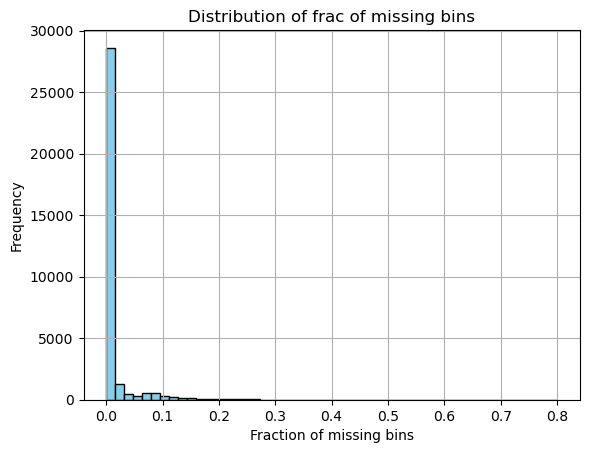

In [9]:
plt.hist(new_df["frac_missing_bbox_pm5bins_bins"], bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Fraction of missing bins')
plt.ylabel('Frequency')
plt.title('Distribution of frac of missing bins')
plt.grid(True)
plt.show()

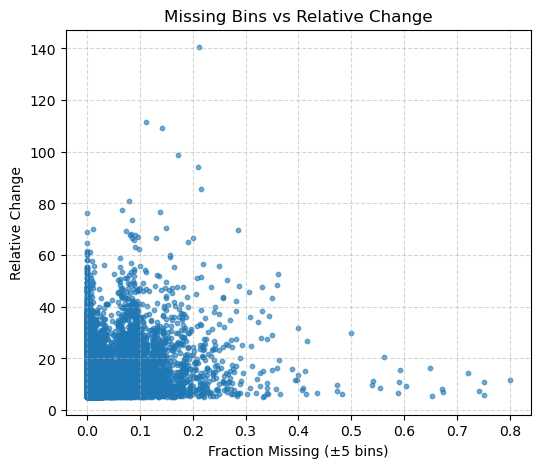

In [10]:
x = new_df["frac_missing_bbox_pm5bins_bins"]
y = new_df["rel_change"]

plt.figure(figsize=(6,5))
plt.scatter(x, y, s=10, alpha=0.6)
plt.xlabel("Fraction Missing (±5 bins)")
plt.ylabel("Relative Change")
plt.title("Missing Bins vs Relative Change")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [11]:
len(new_df[(new_df["frac_missing_bbox_pm5bins_bins"] < 0.1) & (new_df["rel_change"] > 15.0)])

6841

In [12]:
selected_df = new_df[(new_df["frac_missing_bbox_pm5bins_bins"] < 0.1) & (new_df["rel_change"] > 15.0)]

In [15]:
selected_df = selected_df.drop(columns=['top_persistence', 'inner_mean', 'inner_std', 'outer_lsum',
                                        'outer_lsize', 'outer_rsum', 'outer_rsize', 'min', 'q1', 'q2', 'q3',
                                        'max', 'outer_lmean', 'outer_rmean', 'outer_mean'])

In [18]:
selected_df = selected_df.reset_index(drop=True)

In [31]:
# splitting the flames into horizontal and vertical
selected_df["x_length"] = selected_df["end1"] - selected_df["start1"]
selected_df["y_length"] = selected_df["end2"] - selected_df["start2"]

In [32]:
selected_df["orientation"] = np.where(selected_df["x_length"] > selected_df["y_length"], "horizontal", "vertical")

In [34]:
selected_df["midpoint"] = np.where(selected_df["orientation"] == "horizontal",
                                                selected_df["start1"],
                                                selected_df["end2"])

In [37]:
selected_df["window_start"] = selected_df["midpoint"] - (320 * 2048) # the entire input seq is 640 bins * 2048bp per bin
selected_df["window_end"] = selected_df["midpoint"] + (320 * 2048)

In [40]:
selected_df.to_csv(f"/scratch1/smaruj/stripepy_stripes/selected_stripes.tsv", sep="\t", index=False)

## Checking stripes with high missing bins fraction

In [41]:
new_df[new_df["frac_missing_bbox_pm5bins_bins"] > 0.7]

,chrom1,start1,end1,chrom2,start2,end2,top_persistence,inner_mean,inner_std,outer_lsum,...,min,q1,q2,q3,max,outer_lmean,outer_rmean,outer_mean,rel_change,frac_missing_bbox_pm5bins_bins
7681,chr4,41623552,42950656,chr4,41598976,41656320,0.053949,0.081482,0.176318,36.284148,...,0.0,0.0,0.0,0.0,0.947063,0.074201,0.068378,0.071289,14.297224,0.720930
7683,chr4,41656320,42942464,chr4,41656320,41689088,0.064340,0.061718,0.150054,34.240595,...,0.0,0.0,0.0,0.0,0.947063,0.072238,0.060912,0.066575,7.295126,0.742515
7686,chr4,42917888,42975232,chr4,41762816,42950656,0.155589,0.052239,0.153311,18.152276,...,0.0,0.0,0.0,0.0,0.916171,0.041444,0.052092,0.046768,11.699178,0.800000
7688,chr4,43016192,43057152,chr4,41762816,43032576,0.058533,0.066109,0.161279,28.396313,...,0.0,0.0,0.0,0.0,0.924041,0.060676,0.058651,0.059664,10.802301,0.751515
23494,chr14,26312704,26378240,chr14,25870336,26345472,0.211349,0.081921,0.186675,10.894243,...,0.0,0.0,0.0,0.0,0.840066,0.061549,0.112184,0.086867,5.692778,0.751634


In [42]:
from matplotlib.colors import LogNorm

In [44]:
# Get stripe info
stripe = new_df.iloc[23494]
chrom = stripe['chrom1']

# Stripe bounds
stripe_x_start = stripe['start1']
stripe_x_end = stripe['end1']
stripe_y_start = stripe['start2']
stripe_y_end = stripe['end2']

# Stripe vertical center (x-axis) and height
stripe_x_center = (stripe_x_start + stripe_x_end) // 2
stripe_width = stripe_x_end - stripe_x_start

# We'll use the same size for X and Y to keep square view
region_size = max(stripe_width * 4, 1_000_000)  # Can adjust multiplier

# Define region so that stripe is vertically centered
region_start = stripe_x_center - region_size // 2
region_end = stripe_x_center + region_size // 2
region = f"{chrom}:{region_start}-{region_end}"

In [45]:
# Fetch raw (unbalanced) matrix
matrix = clr.matrix(balance=False).fetch(region)

# Plot extents
extents = (region_start, region_end, region_end, region_start)

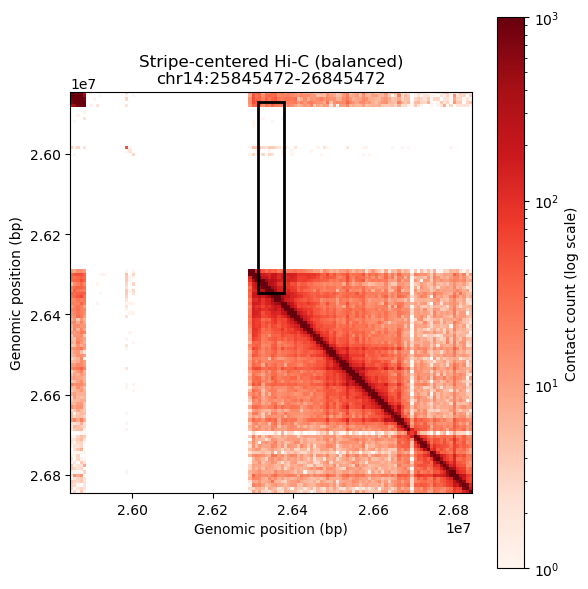

In [46]:
# for balanced data
norm = LogNorm(vmin=1.0, vmax=1000)

# Plot
plt.figure(figsize=(6, 6))
plt.imshow(
    matrix,
    cmap='Reds',
    norm=norm,
    extent=extents,
    origin='upper'
)

# Add rectangle or lines to show stripe
# If the stripe is vertical (typical for vertical stripe from loop extrusion):
stripe_rect = patches.Rectangle(
    (stripe_x_start, stripe_y_start),
    stripe_x_end - stripe_x_start,
    stripe_y_end - stripe_y_start,
    linewidth=2,
    edgecolor='black',
    facecolor='none'
)
plt.gca().add_patch(stripe_rect)

# plt.title(f"Stripe-centered Hi-C (raw counts)\n{region}")
plt.title(f"Stripe-centered Hi-C (balanced)\n{region}")
plt.xlabel("Genomic position (bp)")
plt.ylabel("Genomic position (bp)")
plt.colorbar(label="Contact count (log scale)")
plt.tight_layout()
plt.show()